In [29]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/harshalkarangale/avengerss/avengers_scenes_only.json
/kaggle/input/datasets/harshalkarangale/script2/500_summer_scenes_only.json
/kaggle/input/datasets/harshalkarangale/script2/avatar_scenes_only.json
/kaggle/input/datasets/harshalkarangale/script2/apocalypse_scenes_only.json


In [2]:
!pip install datasets

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from transformers import BertTokenizer, BertModel
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader

import numpy as np
from sklearn.metrics import f1_score

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
dataset = load_dataset("go_emotions")

train_data = dataset["train"]
dev_data   = dataset["validation"]
test_data  = dataset["test"]

README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [6]:
from collections import Counter
label_counter = Counter()

for item in train_data:
    label_counter.update(item["labels"])

In [7]:
valid_labels = [label for label, count in label_counter.items() if count > 2000]

print("Number of selected emotions:", len(valid_labels))
print(valid_labels)

Number of selected emotions: 9
[27, 3, 15, 0, 1, 4, 7, 18, 10]


In [8]:
def filter_dataset(data):

    filtered = []

    for item in data:

        new_labels = [l for l in item["labels"] if l in valid_labels]

        if len(new_labels) > 0:
            filtered.append({
                "text": item["text"],
                "labels": new_labels
            })

    return filtered

In [9]:
train_data = filter_dataset(train_data)
dev_data   = filter_dataset(dev_data)
test_data  = filter_dataset(test_data)

In [10]:
def remap_labels(labels):
    return [label_map[l] for l in labels]

In [11]:
label_names = dataset["train"].features["labels"].feature.names

print([label_names[i] for i in valid_labels])

['neutral', 'annoyance', 'gratitude', 'admiration', 'amusement', 'approval', 'curiosity', 'love', 'disapproval']


In [12]:
label_map = {old:i for i, old in enumerate(valid_labels)}

NUM_CLASSES = len(valid_labels)

print("Classes:", NUM_CLASSES)

Classes: 9


In [13]:
def multi_hot(labels):

    vec = np.zeros(NUM_CLASSES)

    for l in labels:
        vec[l] = 1

    return vec

In [14]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

bert_model = BertModel.from_pretrained("bert-base-uncased")
bert_model.to(device)
bert_model.eval()  # freeze BERT

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [15]:
MAX_LEN = 64

In [16]:
class GoEmotionDataset(Dataset):

    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        text = self.data[idx]["text"]
        labels = remap_labels(self.data[idx]["labels"])

        encoding = tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        y = torch.tensor(multi_hot(labels), dtype=torch.float)

        return input_ids, attention_mask, y

In [17]:
train_loader = DataLoader(
    GoEmotionDataset(train_data),
    batch_size=16,
    shuffle=True
)

dev_loader = DataLoader(
    GoEmotionDataset(dev_data),
    batch_size=16
)

In [11]:
class BERT_BiLSTM(nn.Module):

    def __init__(self, hidden_dim=128):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=768,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(hidden_dim*2, NUM_CLASSES)

    def forward(self, embeddings):

        lstm_out, _ = self.lstm(embeddings)

        pooled = torch.mean(lstm_out, dim=1)

        logits = self.fc(self.dropout(pooled))

        return logits

In [28]:
train_loader = DataLoader(
    GoEmotionDataset(train_data),
    batch_size=16,
    shuffle=True
)

dev_loader = DataLoader(
    GoEmotionDataset(dev_data),
    batch_size=16
)

In [29]:
class BERT_BiLSTM(nn.Module):

    def __init__(self, hidden_dim=128):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=768,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(hidden_dim*2, NUM_CLASSES)

    def forward(self, embeddings):

        lstm_out, _ = self.lstm(embeddings)

        pooled = torch.mean(lstm_out, dim=1)

        logits = self.fc(self.dropout(pooled))

        return logits

In [30]:
model = BERT_BiLSTM().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(model.parameters(), lr=2e-4)

In [18]:
def train_epoch(loader):

    model.train()
    total_loss = 0

    for input_ids, attention_mask, labels in loader:

        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            outputs = bert_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            embeddings = outputs.last_hidden_state

        logits = model(embeddings)

        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Loss:", total_loss/len(loader))

In [24]:
def evaluate(loader):

    model.eval()

    preds = []
    truths = []

    with torch.no_grad():

        for input_ids, attention_mask, labels in loader:

            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)

            outputs = bert_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            embeddings = outputs.last_hidden_state

            logits = model(embeddings)

            pred = torch.sigmoid(logits).cpu().numpy()
            pred = (pred > 0.5).astype(int)

            preds.extend(pred)
            truths.extend(labels.numpy())

    print("Macro F1:", f1_score(truths, preds, average="macro"))

In [33]:
for epoch in range(5):

    print("Epoch", epoch+1)

    train_epoch(train_loader)

    evaluate(dev_loader)

Epoch 1
Loss: 0.24718337280447408
Macro F1: 0.4323803273892751
Epoch 2
Loss: 0.20017624851857307
Macro F1: 0.4783959797276094
Epoch 3
Loss: 0.18253752088485123
Macro F1: 0.5258292635173589
Epoch 4
Loss: 0.171306290473479
Macro F1: 0.568598080842801
Epoch 5
Loss: 0.16234347195988627
Macro F1: 0.5634376517892954


In [35]:
for epoch in range(10):

    print("Epoch", epoch+1)

    train_epoch(train_loader)

    evaluate(dev_loader)

Epoch 1
Loss: 0.053851344964867306
Macro F1: 0.5960887599539918
Epoch 2
Loss: 0.048354584943472875
Macro F1: 0.6051906762092873
Epoch 3
Loss: 0.04335433461119621
Macro F1: 0.5964986143938195
Epoch 4
Loss: 0.03989130549306157
Macro F1: 0.5904621215900376
Epoch 5
Loss: 0.03591363847607418
Macro F1: 0.5945301804428968
Epoch 6
Loss: 0.0330247261813314
Macro F1: 0.5895902041267722
Epoch 7
Loss: 0.030803547350789277
Macro F1: 0.5935313417590184
Epoch 8
Loss: 0.02936202679135516
Macro F1: 0.601694949030105
Epoch 9
Loss: 0.025436793685389078
Macro F1: 0.601118380417749
Epoch 10
Loss: 0.024506781061085014
Macro F1: 0.5848799839653944


In [19]:
from sklearn.metrics import accuracy_score

def evaluate_with_accuracy(loader):

    model.eval()

    preds = []
    truths = []

    with torch.no_grad():

        for input_ids, attention_mask, labels in loader:

            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)

            outputs = bert_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            embeddings = outputs.last_hidden_state

            logits = model(embeddings)

            pred = torch.sigmoid(logits).cpu().numpy()
            pred = (pred > 0.5).astype(int)

            preds.extend(pred)
            truths.extend(labels.numpy())

    macro_f1 = f1_score(truths, preds, average="macro")

    acc = accuracy_score(truths, preds)

    print("Macro F1:", macro_f1)
    print("Accuracy:", acc)

In [38]:
test_loader = DataLoader(
    GoEmotionDataset(test_data),
    batch_size=16
)

In [39]:
evaluate_with_accuracy(test_loader)

Macro F1: 0.602617355164483
Accuracy: 0.5749506903353058


In [41]:
import numpy as np
import matplotlib.pyplot as plt

token_lengths = []

for item in train_data:

    text = item["text"]

    tokens = tokenizer.tokenize(text)

    token_lengths.append(len(tokens))


token_lengths = np.array(token_lengths)

print("Average token length:", np.mean(token_lengths))
print("Median token length:", np.median(token_lengths))
print("Max token length:", np.max(token_lengths))

print("90th percentile:", np.percentile(token_lengths, 90))
print("95th percentile:", np.percentile(token_lengths, 95))
print("99th percentile:", np.percentile(token_lengths, 99))

Average token length: 17.01037178382371
Median token length: 16.0
Max token length: 314
90th percentile: 29.0
95th percentile: 32.0
99th percentile: 36.0


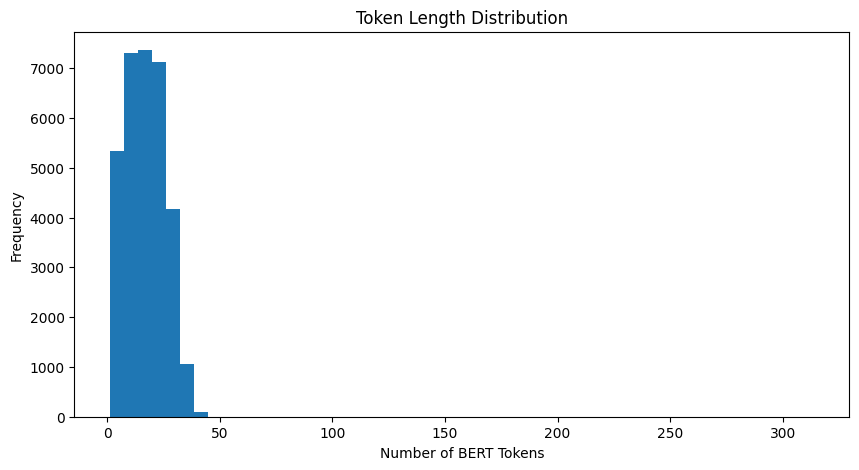

In [42]:
plt.figure(figsize=(10,5))

plt.hist(token_lengths, bins=50)

plt.title("Token Length Distribution")
plt.xlabel("Number of BERT Tokens")
plt.ylabel("Frequency")

plt.show()

In [20]:
class AttentionLayer(nn.Module):

    def __init__(self, hidden_dim):
        super().__init__()

        self.attention = nn.Linear(hidden_dim*2, 1)

    def forward(self, lstm_output):

        # lstm_output shape
        # (batch_size, seq_len, hidden_dim*2)

        scores = self.attention(lstm_output)

        weights = torch.softmax(scores, dim=1)

        context = torch.sum(weights * lstm_output, dim=1)

        return context

In [21]:
class BERT_BiLSTM(nn.Module):

    def __init__(self, hidden_dim=128):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=768,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        self.attention = AttentionLayer(hidden_dim)

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(hidden_dim*2, NUM_CLASSES)

    def forward(self, embeddings):

        lstm_out, _ = self.lstm(embeddings)

        context = self.attention(lstm_out)

        logits = self.fc(self.dropout(context))

        return logits

In [22]:
model = BERT_BiLSTM().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(model.parameters(), lr=2e-4)

#Train the model , run the trianing cell

In [ ]:
for epoch in range(5):

    print("Epoch", epoch+1)

    train_epoch(train_loader)

    evaluate(dev_loader)

Epoch 1
Loss: 0.24790569006707033
Macro F1: 0.4537578598699043
Epoch 2
Loss: 0.19315615601577177
Macro F1: 0.555171607900506
Epoch 3
Loss: 0.1756755594386073
Macro F1: 0.5506588551972613
Epoch 4
Loss: 0.16346798744006794
Macro F1: 0.5789344373616185
Epoch 5


In [52]:
for epoch in range(15):

    print("Epoch", epoch+1)

    train_epoch(train_loader)

    evaluate(dev_loader)

Epoch 1
Loss: 0.14035278932910902
Macro F1: 0.5821728071580075
Epoch 2
Loss: 0.12606535998050625
Macro F1: 0.6153532000985443
Epoch 3
Loss: 0.10992784136910852
Macro F1: 0.6160061223887667
Epoch 4
Loss: 0.09308549193624116
Macro F1: 0.599476593063992
Epoch 5
Loss: 0.07799081166665991
Macro F1: 0.5980960789198762
Epoch 6
Loss: 0.06474217748684888
Macro F1: 0.5896280341963878
Epoch 7
Loss: 0.05545120161569644
Macro F1: 0.6052774915044676
Epoch 8
Loss: 0.04593476295702303
Macro F1: 0.5967338415363024
Epoch 9
Loss: 0.040527745923953674
Macro F1: 0.5891213974218074
Epoch 10
Loss: 0.036055377965627015
Macro F1: 0.5835581896945603
Epoch 11
Loss: 0.031504079931257874
Macro F1: 0.5938032163710344
Epoch 12
Loss: 0.027219363756453528
Macro F1: 0.5996629504560861
Epoch 13
Loss: 0.02443220750457969
Macro F1: 0.5963527360035032
Epoch 14
Loss: 0.023237881141429072
Macro F1: 0.5818276557293338
Epoch 15
Loss: 0.021185409798565886
Macro F1: 0.60022104394071


Even after replacing the pooling layer with the attention layer , there is no improvement in the macro F1- score

In [23]:
for epoch in range(15):

    print("Epoch", epoch+1)

    train_epoch(train_loader)

    evaluate(dev_loader)

Epoch 1
Loss: 0.24644745567172457


NameError: name 'evaluate' is not defined

In [25]:
evaluate(dev_loader)

Macro F1: 0.43583812203124705


In [26]:
for epoch in range(15):

    print("Epoch", epoch+1)

    train_epoch(train_loader)

    evaluate(dev_loader)

Epoch 1
Loss: 0.19064185518912644
Macro F1: 0.5354036544081268
Epoch 2
Loss: 0.17455979114181006
Macro F1: 0.5749648766652318
Epoch 3
Loss: 0.16267287113407103
Macro F1: 0.5852366685360813
Epoch 4
Loss: 0.15160413357144445
Macro F1: 0.609838208405015
Epoch 5
Loss: 0.1385025833277119
Macro F1: 0.6049281485307263
Epoch 6
Loss: 0.12395319261265793
Macro F1: 0.59562636813037
Epoch 7
Loss: 0.10785545748422323
Macro F1: 0.6034991495112911
Epoch 8
Loss: 0.09194717954675488
Macro F1: 0.6107721128923619
Epoch 9
Loss: 0.0771818136725738
Macro F1: 0.5946626919731932
Epoch 10
Loss: 0.06485211553262085
Macro F1: 0.6021229442048006
Epoch 11
Loss: 0.05413453314377244


KeyboardInterrupt: 

In [28]:
torch.save(model.state_dict(), "/kaggle/working/bilstm_model.pt")

In [27]:
torch.save(bert_model.state_dict(), "/kaggle/working/bert_backbone.pt")
print("✓ BERT backbone saved.")

✓ BERT backbone saved.


Device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ BiLSTM + BERT loaded successfully.
500 Days of Summer: 107 scenes
GT distribution  : Counter({'Negative_Distressing': 44, 'Neutral_Complex': 35, 'Positive_Uplifting': 27, 'Tension_Action': 1})

── BiLSTM Direct Test — 500 Days of Summer ──
Accuracy : 34/107 = 31.8%

Classification Report:
                      precision    recall  f1-score   support

  Positive_Uplifting       0.27      0.26      0.26        27
     Neutral_Complex       0.34      0.71      0.46        35
      Tension_Action       0.00      0.00      0.00         1
Negative_Distressing       0.50      0.05      0.08        44

            accuracy                           0.32       107
           macro avg       0.28      0.25      0.20       107
        weighted avg       0.38      0.32      0.25       107



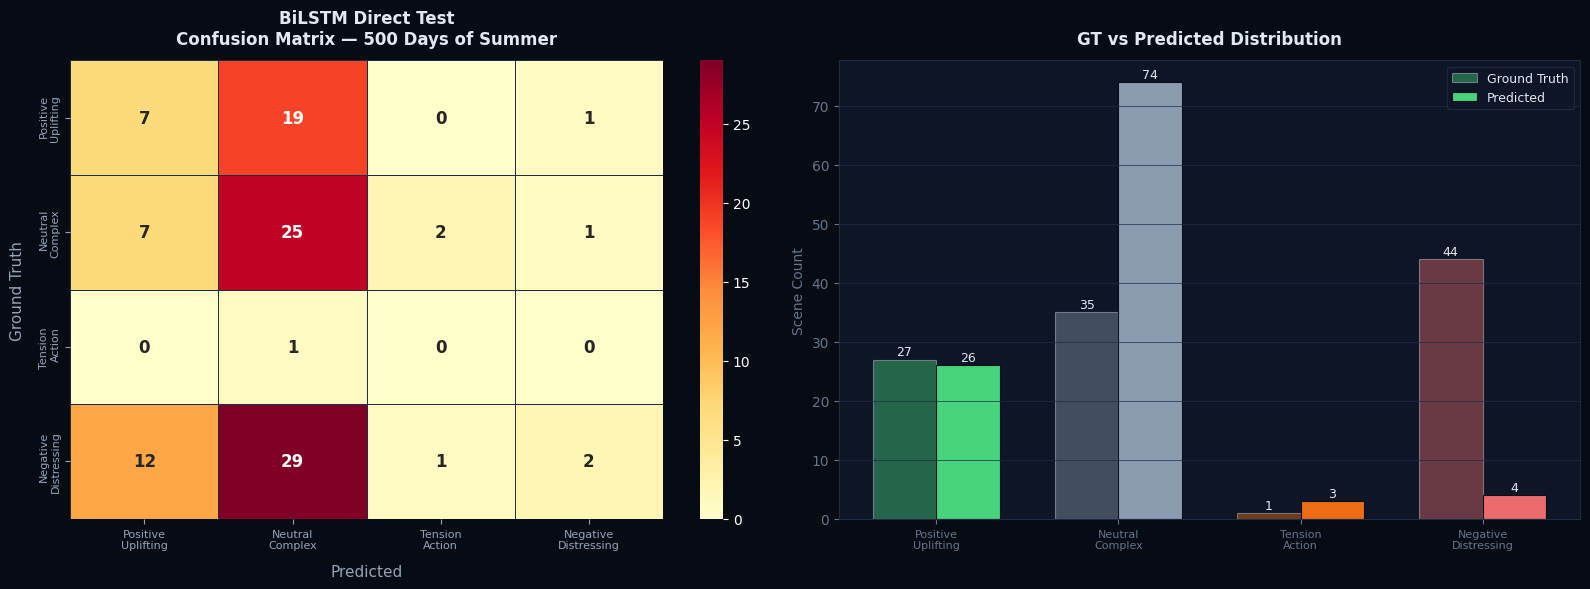


Total scenes after mapping: 358
Distribution: Counter({'Negative_Distressing': 109, 'Tension_Action': 100, 'Neutral_Complex': 91, 'Positive_Uplifting': 58})

Min class count : 58
Test per class  : 11
Train per class : 47 (balanced) + extras from larger classes

Train: 314 scenes | Test: 44 scenes
Train dist: Counter({'Negative_Distressing': 98, 'Tension_Action': 89, 'Neutral_Complex': 80, 'Positive_Uplifting': 47})
Test  dist: Counter({'Negative_Distressing': 11, 'Tension_Action': 11, 'Neutral_Complex': 11, 'Positive_Uplifting': 11})  ← perfectly balanced


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✓ Adapted BiLSTM ready
  Trainable: 30,258,181 / 110,798,341  (27.3%)
Class weights: {'Positive_Uplifting': 1.67, 'Neutral_Complex': 0.98, 'Tension_Action': 0.88, 'Negative_Distressing': 0.8}

── BiLSTM Domain Adaptation Training ──
   Train: 314 | Test: 44 (balanced)

Epoch  1/40  train_loss=1.4500  train_acc=0.268  test_loss=1.4484  test_acc=0.227  macro_f1=0.1409  gap=0.040
  ✓ New best saved  (macro_f1=0.1409)
Epoch  2/40  train_loss=1.4382  train_acc=0.239  test_loss=1.4308  test_acc=0.205  macro_f1=0.1129  gap=0.034
Epoch  3/40  train_loss=1.3961  train_acc=0.290  test_loss=1.4270  test_acc=0.250  macro_f1=0.1421  gap=0.040
  ✓ New best saved  (macro_f1=0.1421)
Epoch  4/40  train_loss=1.3572  train_acc=0.360  test_loss=1.4640  test_acc=0.250  macro_f1=0.1468  gap=0.110
  ✓ New best saved  (macro_f1=0.1468)
Epoch  5/40  train_loss=1.3061  train_acc=0.404  test_loss=1.4234  test_acc=0.295  macro_f1=0.2470  gap=0.109
  ✓ New best saved  (macro_f1=0.2470)
Epoch  6/40  train_loss=1.2

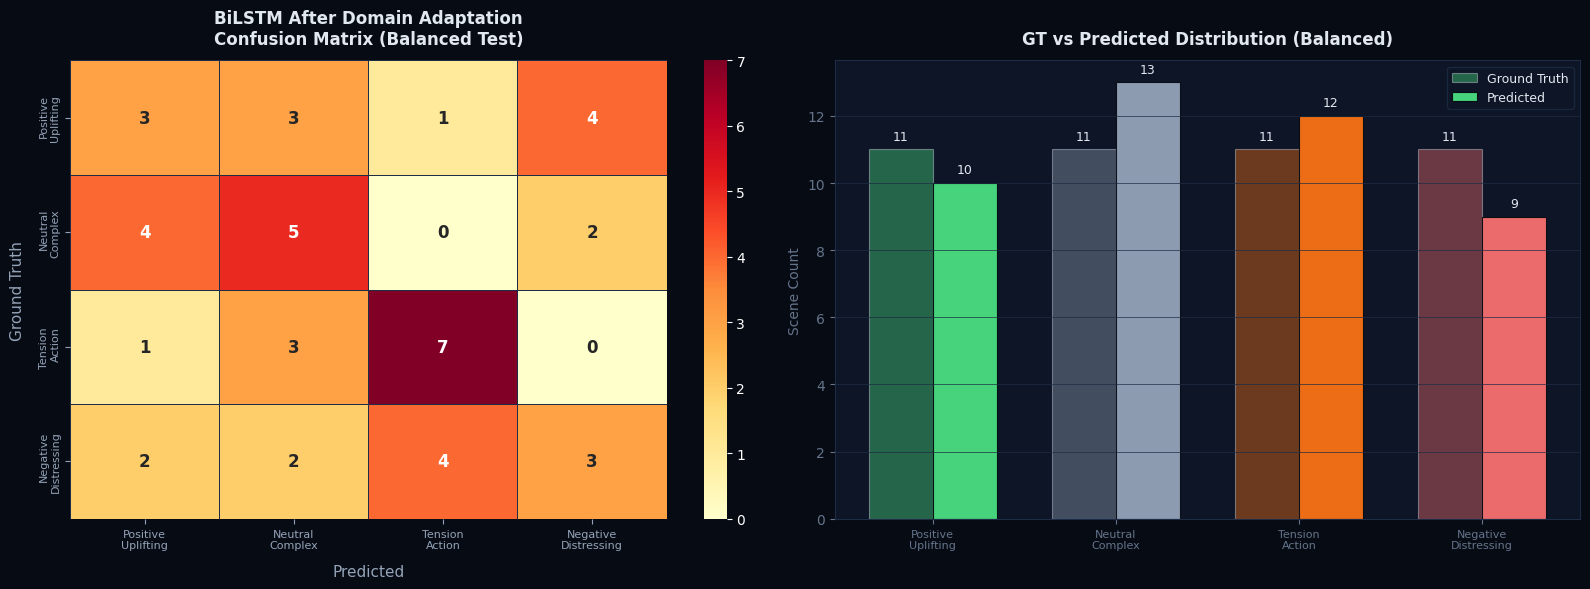


── BiLSTM Summary ──
  Direct test (Summer, no adapt) : see Part 1 results
  After domain adaptation        : Accuracy=40.9%  Macro F1=0.4028

✓ Adapted BiLSTM saved: /kaggle/working/bilstm_adapted.pt


In [30]:
# ═══════════════════════════════════════════════════════════════
#  BILSTM — PART 1: Direct Inference on 500 Days of Summer
#  No adaptation — just test GoEmotions trained weights directly
# ═══════════════════════════════════════════════════════════════

# ── CELL 1: Imports ──
import json, re, math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, get_cosine_schedule_with_warmup
from collections import Counter
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── CELL 2: Config ──
MAX_LEN     = 64        # must match BiLSTM training
BATCH_SIZE  = 16
NUM_CLASSES = 9         # GoEmotions 9-class output

# GoEmotions label order — must match training label_map exactly
# valid_labels order from your notebook (count > 2000):
# Run: print(valid_labels) in your training notebook to confirm order
# Typical order: [27=neutral, 2=admiration, 0=amusement, 14=gratitude,
#                 11=disapproval, 3=annoyance, 7=curiosity, 17=love, 1=approval]
# We use the emotion names after remapping:
EMOTION_NAMES = ["neutral", "admiration", "amusement", "gratitude",
                 "disapproval", "annoyance", "curiosity", "love", "approval"]

# Emotion → Cinematic Core mapping
# annoyance → Negative_Distressing (not Tension_Action)
EMOTION_TO_CORE = {
    "neutral"     : "Neutral_Complex",
    "annoyance"   : "Negative_Distressing",
    "disapproval" : "Negative_Distressing",
    "curiosity"   : "Tension_Action",
    "gratitude"   : "Positive_Uplifting",
    "admiration"  : "Positive_Uplifting",
    "amusement"   : "Positive_Uplifting",
    "love"        : "Positive_Uplifting",
    "approval"    : "Positive_Uplifting",
}

CORE_ORDER  = ["Positive_Uplifting", "Neutral_Complex",
               "Tension_Action",     "Negative_Distressing"]
CORE_COLORS = {
    "Positive_Uplifting"   : "#4ade80",
    "Neutral_Complex"      : "#94a3b8",
    "Tension_Action"       : "#f97316",
    "Negative_Distressing" : "#f87171",
}

# ── Paths ──
BILSTM_PATH  = "/kaggle/working/bilstm_model.pt"
BERT_PATH    = "/kaggle/working/bert_backbone.pt"
SUMMER_PATH  = "/kaggle/input/datasets/harshalkarangale/script2/500_summer_scenes_only.json"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── CELL 3: BiLSTM Architecture (must match training exactly) ──
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_output):
        scores  = self.attention(lstm_output)
        weights = torch.softmax(scores, dim=1)
        context = torch.sum(weights * lstm_output, dim=1)
        return context


class BERT_BiLSTM(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=768,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )
        self.attention = AttentionLayer(hidden_dim)
        self.dropout   = nn.Dropout(0.3)
        self.fc        = nn.Linear(hidden_dim * 2, NUM_CLASSES)

    def forward(self, embeddings):
        lstm_out, _ = self.lstm(embeddings)
        context     = self.attention(lstm_out)
        return self.fc(self.dropout(context))


# ── CELL 4: Load models ──
tokenizer  = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")
bert_model.load_state_dict(
    torch.load(BERT_PATH, map_location=device, weights_only=True)
)
bert_model.to(device)
bert_model.eval()

bilstm_model = BERT_BiLSTM().to(device)
bilstm_model.load_state_dict(
    torch.load(BILSTM_PATH, map_location=device, weights_only=True)
)
bilstm_model.eval()
print("✓ BiLSTM + BERT loaded successfully.")

# ── CELL 5: JSON loader ──
def load_script_json(path, name=""):
    with open(path, "r", encoding="utf-8") as f:
        raw = f.read().strip()
    try:
        data = json.loads(raw)
    except json.JSONDecodeError:
        raw  = "[" + raw + "]"
        raw  = re.sub(r',\s*\]', ']', raw)
        data = json.loads(raw)
    if isinstance(data, dict):
        data = data.get("scenes", list(data.values())[0])
    scenes = []
    for s in data:
        text = str(s.get("scene_text", "")).strip()
        core = s.get("emotional_core")
        if text and core is not None:
            scenes.append({
                "text"  : text,
                "core"  : core.strip(),
                "source": name
            })
    return scenes

EXTENDED_CORE_MAP = {
    "Positive_Uplifting"   : "Positive_Uplifting",
    "Neutral_Complex"      : "Neutral_Complex",
    "Tension_Action"       : "Tension_Action",
    "Negative_Distressing" : "Negative_Distressing",
    "Awe_Wonder"           : "Positive_Uplifting",
    "Heroic_Triumph"       : "Positive_Uplifting",
    "Epic_Grandiose"       : "Tension_Action",
    "Dread_Fear"           : "Negative_Distressing",
    "Sacrifice"            : "Negative_Distressing",
    "Grief_Loss"           : "Negative_Distressing",
    "Anger_Defiance"       : "Tension_Action",
    "Suspense_Unease"      : "Tension_Action",
    "Determination"        : "Tension_Action",
    "Relief_Catharsis"     : "Positive_Uplifting",
    "Melancholy_Longing"   : "Negative_Distressing",
    "Humor_Levity"         : "Positive_Uplifting",
    "Shock_Disbelief"      : "Negative_Distressing",
    "Camaraderie_Bonding"  : "Positive_Uplifting",
    "Urgency_Desperation"  : "Tension_Action",
}

summer_scenes = load_script_json(SUMMER_PATH, "Summer")
summer_scenes = [s for s in summer_scenes
                 if EXTENDED_CORE_MAP.get(s["core"]) is not None]
for s in summer_scenes:
    s["core"] = EXTENDED_CORE_MAP[s["core"]]

texts_summer = [s["text"] for s in summer_scenes]
gt_summer    = [s["core"] for s in summer_scenes]

print(f"500 Days of Summer: {len(texts_summer)} scenes")
print(f"GT distribution  : {Counter(gt_summer)}")

# ── CELL 6: Inference dataset ──
class SceneInferenceDataset(Dataset):
    def __init__(self, texts):
        self.texts = [str(t) for t in texts]
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx], padding="max_length",
            truncation=True, max_length=MAX_LEN, return_tensors="pt"
        )
        return enc["input_ids"].squeeze(0), enc["attention_mask"].squeeze(0)

# ── CELL 7: Run inference ──
loader_summer = DataLoader(
    SceneInferenceDataset(texts_summer),
    batch_size=BATCH_SIZE, shuffle=False
)

all_probs = []
with torch.no_grad():
    for input_ids, mask in loader_summer:
        input_ids = input_ids.to(device)
        mask      = mask.to(device)
        # Get BERT embeddings
        bert_out  = bert_model(input_ids=input_ids,
                               attention_mask=mOurask).last_hidden_state
        logits    = bilstm_model(bert_out)
        probs     = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)

probs_summer = np.vstack(all_probs)

# Map to cinematic cores using max probability per core
def probs_to_core(prob_row):
    core_scores = {c: 0.0 for c in CORE_ORDER}
    for j, ename in enumerate(EMOTION_NAMES):
        core = EMOTION_TO_CORE[ename]
        core_scores[core] = max(core_scores[core], float(prob_row[j]))
    return max(core_scores, key=core_scores.get)

pred_cores_summer = [probs_to_core(p) for p in probs_summer]

# ── CELL 8: Metrics ──
print("\n── BiLSTM Direct Test — 500 Days of Summer ──")
correct = sum(p == g for p, g in zip(pred_cores_summer, gt_summer))
print(f"Accuracy : {correct}/{len(pred_cores_summer)} = {correct/len(pred_cores_summer)*100:.1f}%")
print(f"\nClassification Report:")
print(classification_report(gt_summer, pred_cores_summer,
                             labels=CORE_ORDER, zero_division=0))

# Confusion matrix
cm = confusion_matrix(gt_summer, pred_cores_summer, labels=CORE_ORDER)
plt.style.use("dark_background")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#070b14")

ax = axes[0]
ax.set_facecolor("#0d1526")
sns.heatmap(
    cm, annot=True, fmt="d", cmap="YlOrRd",
    xticklabels=[c.replace("_", "\n") for c in CORE_ORDER],
    yticklabels=[c.replace("_", "\n") for c in CORE_ORDER],
    ax=ax, linewidths=0.5, linecolor="#1e2d45",
    annot_kws={"size": 12, "weight": "bold"}
)
ax.set_xlabel("Predicted",    color="#94a3b8", fontsize=11, labelpad=10)
ax.set_ylabel("Ground Truth", color="#94a3b8", fontsize=11, labelpad=10)
ax.set_title("BiLSTM Direct Test\nConfusion Matrix — 500 Days of Summer",
             color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax.tick_params(colors="#94a3b8", labelsize=8)

# GT vs Predicted distribution
ax2 = axes[1]
ax2.set_facecolor("#0d1526")
gt_dist   = Counter(gt_summer)
pred_dist = Counter(pred_cores_summer)
x         = np.arange(len(CORE_ORDER))
bw        = 0.35
gt_vals   = [gt_dist.get(c, 0)   for c in CORE_ORDER]
pred_vals = [pred_dist.get(c, 0) for c in CORE_ORDER]
b1 = ax2.bar(x - bw/2, gt_vals,   bw, label="Ground Truth",
             color=[CORE_COLORS[c] for c in CORE_ORDER],
             alpha=0.4, edgecolor="#e2e8f0", linewidth=0.8)
b2 = ax2.bar(x + bw/2, pred_vals, bw, label="Predicted",
             color=[CORE_COLORS[c] for c in CORE_ORDER],
             alpha=0.95, edgecolor="#070b14", linewidth=0.8)
for bar, val in zip(list(b1) + list(b2), gt_vals + pred_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(val), ha="center", va="bottom", fontsize=9, color="#e2e8f0")
ax2.set_xticks(x)
ax2.set_xticklabels([c.replace("_", "\n") for c in CORE_ORDER],
                    fontsize=8, color="#94a3b8")
ax2.set_ylabel("Scene Count",  color="#64748b", fontsize=10)
ax2.set_title("GT vs Predicted Distribution",
              color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax2.tick_params(colors="#64748b")
ax2.legend(fontsize=9, facecolor="#0d1526", edgecolor="#1e2d45", labelcolor="#e2e8f0")
ax2.grid(axis="y", color="#1e2d45", linewidth=0.5)
for spine in ax2.spines.values():
    spine.set_edgecolor("#1e2d45")
plt.tight_layout()
plt.savefig("/kaggle/working/bilstm_direct_test.png",
            dpi=150, bbox_inches="tight", facecolor="#070b14")
plt.show()


# ═══════════════════════════════════════════════════════════════
#  BILSTM — PART 2: Domain Adaptation on All 3 Scripts
#  Balanced test set — equal samples per class
# ═══════════════════════════════════════════════════════════════

# ── CELL 9: Load all 3 scripts ──
AVATAR_PATH   = "/kaggle/input/datasets/harshalkarangale/script2/avatar_scenes_only.json"
AVENGERS_PATH = "/kaggle/input/datasets/harshalkarangale/avengerss/avengers_scenes_only.json"

avatar_scenes   = load_script_json(AVATAR_PATH,   "Avatar")
avengers_scenes = load_script_json(AVENGERS_PATH, "Avengers")

# Apply core mapping to all scripts
def apply_core_map(scenes):
    out = []
    for s in scenes:
        mapped = EXTENDED_CORE_MAP.get(s["core"].strip())
        if mapped:
            out.append({"text": s["text"], "core": mapped, "source": s["source"]})
    return out

summer_mapped   = apply_core_map(summer_scenes)
avatar_mapped   = apply_core_map(avatar_scenes)
avengers_mapped = apply_core_map(avengers_scenes)

all_scenes = summer_mapped + avatar_mapped + avengers_mapped
print(f"\nTotal scenes after mapping: {len(all_scenes)}")
print(f"Distribution: {Counter(s['core'] for s in all_scenes)}")

# ── CELL 10: Balanced test set ──
# Find minimum class count → use that as test size per class
# to guarantee perfect balance in test set
import random
random.seed(42)

by_class = {c: [] for c in CORE_ORDER}
for s in all_scenes:
    by_class[s["core"]].append(s)

# Shuffle each class
for c in CORE_ORDER:
    random.shuffle(by_class[c])

# Min count across classes
min_count  = min(len(by_class[c]) for c in CORE_ORDER)
test_per_class  = max(5, int(min_count * 0.2))   # 20% of smallest class, min 5
train_per_class = min_count - test_per_class

print(f"\nMin class count : {min_count}")
print(f"Test per class  : {test_per_class}")
print(f"Train per class : {train_per_class} (balanced) + extras from larger classes")

# Build balanced test set
test_scenes  = []
train_scenes = []

for c in CORE_ORDER:
    scenes_c = by_class[c]
    test_scenes  += scenes_c[:test_per_class]
    train_scenes += scenes_c[test_per_class:]   # all remaining go to train

random.shuffle(train_scenes)
random.shuffle(test_scenes)

train_texts  = [s["text"] for s in train_scenes]
train_labels = [s["core"] for s in train_scenes]
test_texts   = [s["text"] for s in test_scenes]
test_labels  = [s["core"] for s in test_scenes]

print(f"\nTrain: {len(train_texts)} scenes | Test: {len(test_texts)} scenes")
print(f"Train dist: {Counter(train_labels)}")
print(f"Test  dist: {Counter(test_labels)}  ← perfectly balanced")

# ── CELL 11: Core dataset for adaptation ──
CORE_TO_IDX      = {c: i for i, c in enumerate(CORE_ORDER)}
NUM_CORE_CLASSES = len(CORE_ORDER)
DA_DROPOUT       = 0.4
DA_EPOCHS        = 40
PATIENCE         = 7

class CoreDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = [str(t) for t in texts]
        self.labels = [CORE_TO_IDX[l] for l in labels]
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx], padding="max_length",
            truncation=True, max_length=MAX_LEN, return_tensors="pt"
        )
        return (
            enc["input_ids"].squeeze(0),
            enc["attention_mask"].squeeze(0),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

train_loader_da = DataLoader(CoreDataset(train_texts, train_labels),
                              batch_size=BATCH_SIZE, shuffle=True)
test_loader_da  = DataLoader(CoreDataset(test_texts,  test_labels),
                              batch_size=BATCH_SIZE, shuffle=False)

# ── CELL 12: Adapted BiLSTM model ──
class AdaptedBiLSTM(nn.Module):
    """
    Unfreezes BERT during domain adaptation.
    Replaces 9-class head with 4-class cinematic core head.
    """
    def __init__(self, bert, hidden_dim=128):
        super().__init__()
        self.bert = bert
        self.lstm = nn.LSTM(
            input_size=768,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )
        self.attention = AttentionLayer(hidden_dim)
        self.dropout   = nn.Dropout(DA_DROPOUT)
        self.fc        = nn.Linear(hidden_dim * 2, NUM_CORE_CLASSES)

        # Freeze bottom 8 BERT layers
        for param in self.bert.embeddings.parameters():
            param.requires_grad = False
        for i in range(8):
            for param in self.bert.encoder.layer[i].parameters():
                param.requires_grad = False
        # Top 4 layers trainable
        for i in range(8, 12):
            for param in self.bert.encoder.layer[i].parameters():
                param.requires_grad = True

    def forward(self, input_ids, attention_mask):
        bert_out    = self.bert(input_ids=input_ids,
                                attention_mask=attention_mask).last_hidden_state
        lstm_out, _ = self.lstm(bert_out)
        context     = self.attention(lstm_out)
        return self.fc(self.dropout(context))


# Reload fresh BERT for adaptation (don't reuse the frozen one)
bert_for_da = BertModel.from_pretrained("bert-base-uncased")
bert_for_da.load_state_dict(
    torch.load(BERT_PATH, map_location=device, weights_only=True)
)
bert_for_da.to(device)

adapted_bilstm = AdaptedBiLSTM(bert_for_da).to(device)

# Copy trained LSTM + attention weights from original bilstm_model
adapted_bilstm.lstm.load_state_dict(bilstm_model.lstm.state_dict())
adapted_bilstm.attention.load_state_dict(bilstm_model.attention.state_dict())
# fc head is new (4 classes) so we don't copy it

total     = sum(p.numel() for p in adapted_bilstm.parameters())
trainable = sum(p.numel() for p in adapted_bilstm.parameters() if p.requires_grad)
print(f"\n✓ Adapted BiLSTM ready")
print(f"  Trainable: {trainable:,} / {total:,}  ({trainable/total*100:.1f}%)")

# ── CELL 13: Loss + Optimizer ──
train_dist  = Counter(train_labels)
total_train = len(train_labels)
weights     = torch.tensor(
    [total_train / (NUM_CORE_CLASSES * train_dist.get(c, 1)) for c in CORE_ORDER],
    dtype=torch.float
).to(device)
print(f"Class weights: { {c: round(w.item(),2) for c,w in zip(CORE_ORDER, weights)} }")

criterion_da = nn.CrossEntropyLoss(weight=weights)

bert_top_params = (list(adapted_bilstm.bert.encoder.layer[8:].parameters()) +
                   list(adapted_bilstm.bert.pooler.parameters()))
custom_params   = (list(adapted_bilstm.lstm.parameters()) +
                   list(adapted_bilstm.attention.parameters()) +
                   list(adapted_bilstm.fc.parameters()))

optimizer_da = optim.AdamW([
    {"params": bert_top_params, "lr": 1e-5, "weight_decay": 0.01},
    {"params": custom_params,   "lr": 5e-5, "weight_decay": 0.01},
])

total_steps  = len(train_loader_da) * DA_EPOCHS
warmup_steps = int(total_steps * 0.1)
scheduler_da = get_cosine_schedule_with_warmup(
    optimizer_da, warmup_steps, total_steps
)

# ── CELL 14: Train / Eval functions ──
def da_train_epoch():
    adapted_bilstm.train()
    total_loss, correct, total = 0.0, 0, 0
    for input_ids, mask, labels in train_loader_da:
        input_ids = input_ids.to(device)
        mask      = mask.to(device)
        labels    = labels.to(device)
        logits    = adapted_bilstm(input_ids, mask)
        loss      = criterion_da(logits, labels)
        optimizer_da.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(adapted_bilstm.parameters(), 1.0)
        optimizer_da.step()
        scheduler_da.step()
        total_loss += loss.item()
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(train_loader_da), correct / total


@torch.no_grad()
def da_eval_epoch(loader):
    adapted_bilstm.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for input_ids, mask, labels in loader:
        input_ids = input_ids.to(device)
        mask      = mask.to(device)
        labels    = labels.to(device)
        logits    = adapted_bilstm(input_ids, mask)
        loss      = criterion_da(logits, labels)
        total_loss += loss.item()
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds  += preds.cpu().tolist()
        all_labels += labels.cpu().tolist()
    pred_names  = [CORE_ORDER[p] for p in all_preds]
    label_names = [CORE_ORDER[l] for l in all_labels]
    macro_f1    = f1_score(label_names, pred_names,
                           labels=CORE_ORDER, average="macro", zero_division=0)
    return total_loss / len(loader), correct / total, macro_f1, pred_names, label_names

# ── CELL 15: Training loop ──
print(f"\n── BiLSTM Domain Adaptation Training ──")
print(f"   Train: {len(train_texts)} | Test: {len(test_texts)} (balanced)\n")

best_f1, best_state, patience_counter = 0.0, None, 0

for epoch in range(1, DA_EPOCHS + 1):
    tr_loss, tr_acc                       = da_train_epoch()
    te_loss, te_acc, te_f1, preds, labels = da_eval_epoch(test_loader_da)
    gap = tr_acc - te_acc

    print(f"Epoch {epoch:2d}/{DA_EPOCHS}  "
          f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.3f}  "
          f"test_loss={te_loss:.4f}  test_acc={te_acc:.3f}  "
          f"macro_f1={te_f1:.4f}  gap={gap:.3f}")

    if te_f1 > best_f1:
        best_f1          = te_f1
        best_state       = {k: v.cpu().clone() for k,v in adapted_bilstm.state_dict().items()}
        patience_counter = 0
        torch.save(best_state, "/kaggle/working/bilstm_adapted.pt")
        print(f"  ✓ New best saved  (macro_f1={best_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}.")
            break

# ── CELL 16: Final evaluation + plots ──
print("\n── Final Test Evaluation (Balanced Test Set) ──")
adapted_bilstm.load_state_dict({k: v.to(device) for k,v in best_state.items()})
_, test_acc, test_f1, pred_names, label_names = da_eval_epoch(test_loader_da)

print(f"Accuracy : {test_acc*100:.1f}%")
print(f"Macro F1 : {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(label_names, pred_names,
                             labels=CORE_ORDER, zero_division=0))

# Confusion matrix + distribution
cm = confusion_matrix(label_names, pred_names, labels=CORE_ORDER)
plt.style.use("dark_background")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#070b14")

ax = axes[0]
ax.set_facecolor("#0d1526")
sns.heatmap(
    cm, annot=True, fmt="d", cmap="YlOrRd",
    xticklabels=[c.replace("_", "\n") for c in CORE_ORDER],
    yticklabels=[c.replace("_", "\n") for c in CORE_ORDER],
    ax=ax, linewidths=0.5, linecolor="#1e2d45",
    annot_kws={"size": 12, "weight": "bold"}
)
ax.set_xlabel("Predicted",    color="#94a3b8", fontsize=11, labelpad=10)
ax.set_ylabel("Ground Truth", color="#94a3b8", fontsize=11, labelpad=10)
ax.set_title("BiLSTM After Domain Adaptation\nConfusion Matrix (Balanced Test)",
             color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax.tick_params(colors="#94a3b8", labelsize=8)

ax2 = axes[1]
ax2.set_facecolor("#0d1526")
gt_dist   = Counter(label_names)
pred_dist = Counter(pred_names)
x         = np.arange(len(CORE_ORDER))
bw        = 0.35
gt_vals   = [gt_dist.get(c, 0)   for c in CORE_ORDER]
pred_vals = [pred_dist.get(c, 0) for c in CORE_ORDER]
b1 = ax2.bar(x - bw/2, gt_vals,   bw, label="Ground Truth",
             color=[CORE_COLORS[c] for c in CORE_ORDER],
             alpha=0.4, edgecolor="#e2e8f0", linewidth=0.8)
b2 = ax2.bar(x + bw/2, pred_vals, bw, label="Predicted",
             color=[CORE_COLORS[c] for c in CORE_ORDER],
             alpha=0.95, edgecolor="#070b14", linewidth=0.8)
for bar, val in zip(list(b1) + list(b2), gt_vals + pred_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(val), ha="center", va="bottom", fontsize=9, color="#e2e8f0")
ax2.set_xticks(x)
ax2.set_xticklabels([c.replace("_", "\n") for c in CORE_ORDER],
                    fontsize=8, color="#94a3b8")
ax2.set_ylabel("Scene Count",  color="#64748b", fontsize=10)
ax2.set_title("GT vs Predicted Distribution (Balanced)",
              color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax2.tick_params(colors="#64748b")
ax2.legend(fontsize=9, facecolor="#0d1526", edgecolor="#1e2d45", labelcolor="#e2e8f0")
ax2.grid(axis="y", color="#1e2d45", linewidth=0.5)
for spine in ax2.spines.values():
    spine.set_edgecolor("#1e2d45")
plt.tight_layout()
plt.savefig("/kaggle/working/bilstm_adapted_results.png",
            dpi=150, bbox_inches="tight", facecolor="#070b14")
plt.show()

print(f"\n── BiLSTM Summary ──")
print(f"  Direct test (Summer, no adapt) : see Part 1 results")
print(f"  After domain adaptation        : Accuracy={test_acc*100:.1f}%  Macro F1={test_f1:.4f}")
print(f"\n✓ Adapted BiLSTM saved: /kaggle/working/bilstm_adapted.pt")

── BiLSTM Direct Test — 500 Days of Summer (No Adaptation) ──
Accuracy : 34/107 = 31.8%

GT dist  : Counter({'Negative_Distressing': 44, 'Neutral_Complex': 35, 'Positive_Uplifting': 27, 'Tension_Action': 1})
Pred dist: Counter({'Neutral_Complex': 74, 'Positive_Uplifting': 26, 'Negative_Distressing': 4, 'Tension_Action': 3})

Classification Report:
                      precision    recall  f1-score   support

  Positive_Uplifting       0.27      0.26      0.26        27
     Neutral_Complex       0.34      0.71      0.46        35
      Tension_Action       0.00      0.00      0.00         1
Negative_Distressing       0.50      0.05      0.08        44

            accuracy                           0.32       107
           macro avg       0.28      0.25      0.20       107
        weighted avg       0.38      0.32      0.25       107



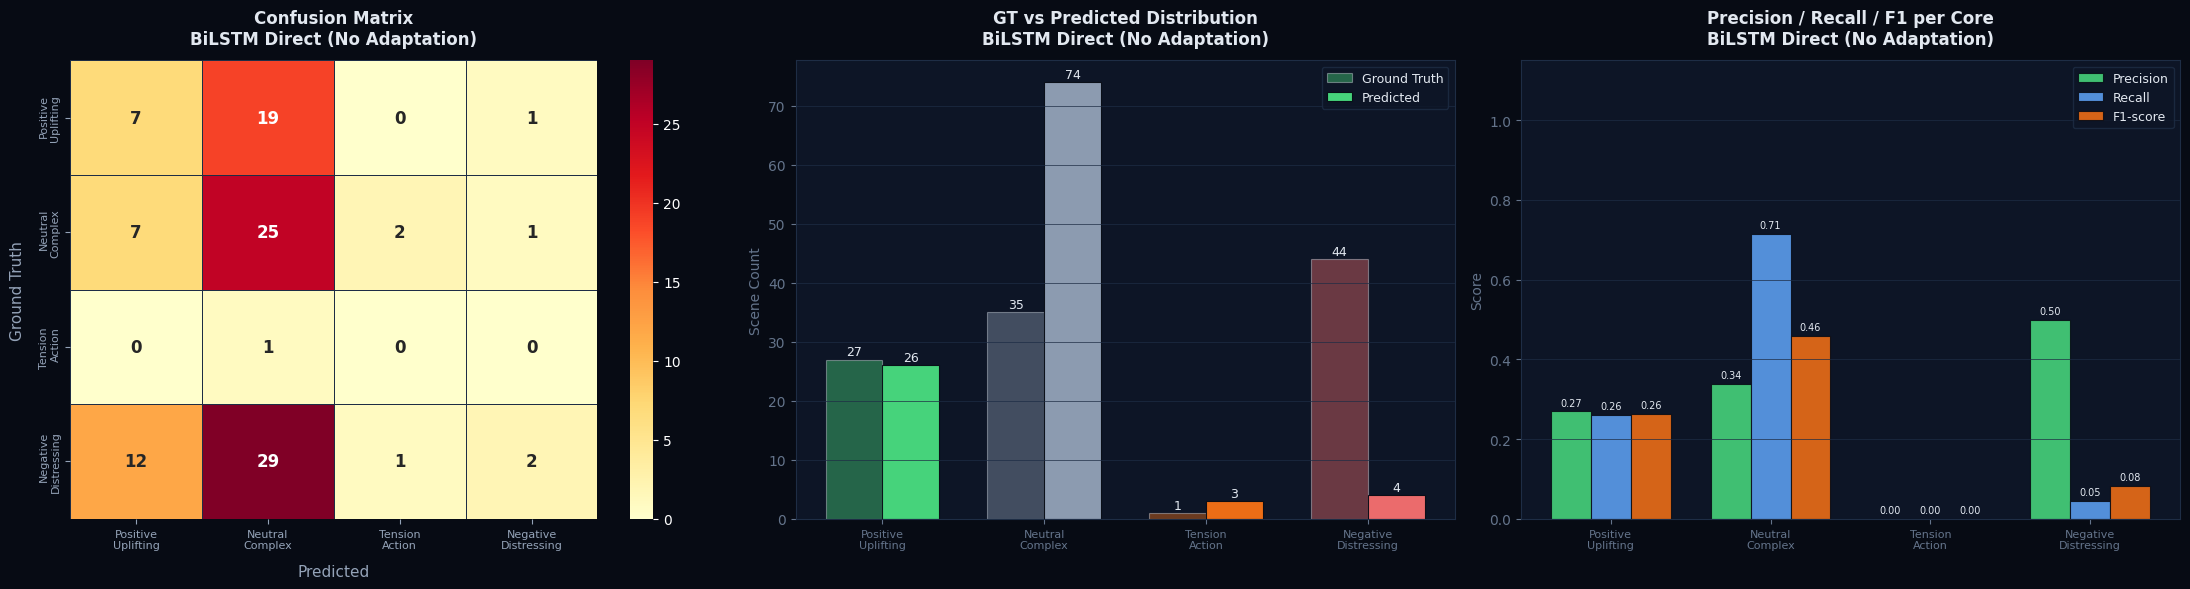

In [32]:
# ── Part 1 Full Report + Graphs ──
print("── BiLSTM Direct Test — 500 Days of Summer (No Adaptation) ──")
correct = sum(p == g for p, g in zip(pred_cores_summer, gt_summer))
print(f"Accuracy : {correct}/{len(pred_cores_summer)} = {correct/len(pred_cores_summer)*100:.1f}%")
print(f"\nGT dist  : {Counter(gt_summer)}")
print(f"Pred dist: {Counter(pred_cores_summer)}")
print(f"\nClassification Report:")
print(classification_report(gt_summer, pred_cores_summer,
                             labels=CORE_ORDER, zero_division=0))

plt.style.use("dark_background")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor("#070b14")

# ── Plot 1: Confusion Matrix ──
cm = confusion_matrix(gt_summer, pred_cores_summer, labels=CORE_ORDER)
ax = axes[0]
ax.set_facecolor("#0d1526")
sns.heatmap(
    cm, annot=True, fmt="d", cmap="YlOrRd",
    xticklabels=[c.replace("_", "\n") for c in CORE_ORDER],
    yticklabels=[c.replace("_", "\n") for c in CORE_ORDER],
    ax=ax, linewidths=0.5, linecolor="#1e2d45",
    annot_kws={"size": 12, "weight": "bold"}
)
ax.set_xlabel("Predicted",    color="#94a3b8", fontsize=11, labelpad=10)
ax.set_ylabel("Ground Truth", color="#94a3b8", fontsize=11, labelpad=10)
ax.set_title("Confusion Matrix\nBiLSTM Direct (No Adaptation)",
             color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax.tick_params(colors="#94a3b8", labelsize=8)

# ── Plot 2: GT vs Predicted Distribution ──
ax2 = axes[1]
ax2.set_facecolor("#0d1526")
gt_dist   = Counter(gt_summer)
pred_dist = Counter(pred_cores_summer)
x         = np.arange(len(CORE_ORDER))
bw        = 0.35
gt_vals   = [gt_dist.get(c, 0)   for c in CORE_ORDER]
pred_vals = [pred_dist.get(c, 0) for c in CORE_ORDER]
b1 = ax2.bar(x - bw/2, gt_vals,   bw, label="Ground Truth",
             color=[CORE_COLORS[c] for c in CORE_ORDER],
             alpha=0.4, edgecolor="#e2e8f0", linewidth=0.8)
b2 = ax2.bar(x + bw/2, pred_vals, bw, label="Predicted",
             color=[CORE_COLORS[c] for c in CORE_ORDER],
             alpha=0.95, edgecolor="#070b14", linewidth=0.8)
for bar, val in zip(list(b1) + list(b2), gt_vals + pred_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(val), ha="center", va="bottom", fontsize=9, color="#e2e8f0")
ax2.set_xticks(x)
ax2.set_xticklabels([c.replace("_", "\n") for c in CORE_ORDER],
                    fontsize=8, color="#94a3b8")
ax2.set_ylabel("Scene Count",  color="#64748b", fontsize=10)
ax2.set_title("GT vs Predicted Distribution\nBiLSTM Direct (No Adaptation)",
              color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax2.tick_params(colors="#64748b")
ax2.legend(fontsize=9, facecolor="#0d1526", edgecolor="#1e2d45", labelcolor="#e2e8f0")
ax2.grid(axis="y", color="#1e2d45", linewidth=0.5)
for spine in ax2.spines.values():
    spine.set_edgecolor("#1e2d45")

# ── Plot 3: Per-class F1 bar chart ──
ax3 = axes[2]
ax3.set_facecolor("#0d1526")
report_dict   = classification_report(
    gt_summer, pred_cores_summer,
    labels=CORE_ORDER, zero_division=0, output_dict=True
)
metrics       = ["precision", "recall", "f1-score"]
metric_colors = ["#4ade80",   "#60a5fa", "#f97316"]
x             = np.arange(len(CORE_ORDER))
bw            = 0.25
for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    vals = [report_dict[c][metric] for c in CORE_ORDER]
    bars = ax3.bar(x + i * bw, vals, bw, label=metric.capitalize(),
                   color=color, alpha=0.85, edgecolor="#070b14", linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha="center", va="bottom",
                 fontsize=7, color="#e2e8f0")
ax3.set_xticks(x + bw)
ax3.set_xticklabels([c.replace("_", "\n") for c in CORE_ORDER],
                    fontsize=8, color="#94a3b8")
ax3.set_ylim(0, 1.15)
ax3.set_ylabel("Score", color="#64748b", fontsize=10)
ax3.set_title("Precision / Recall / F1 per Core\nBiLSTM Direct (No Adaptation)",
              color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax3.tick_params(colors="#64748b")
ax3.legend(fontsize=9, facecolor="#0d1526", edgecolor="#1e2d45", labelcolor="#e2e8f0")
ax3.grid(axis="y", color="#1e2d45", linewidth=0.5)
for spine in ax3.spines.values():
    spine.set_edgecolor("#1e2d45")

plt.tight_layout()
plt.savefig("/kaggle/working/bilstm_direct_full.png",
            dpi=150, bbox_inches="tight", facecolor="#070b14")
plt.show()

In [33]:
print("hello")

hello
